# Лабораторная работа №1
## «Анализ и прогнозирование временных рядов на примере розничных продаж»

**Исходные данные:** `retail_sales_mock_data.csv` — месячные продажи 2020–2023, 48 наблюдений.  
Колонки: `Date`, `SalesAmount`, `Promotion` (флаг акции), `HolidayMonth` (праздничный месяц).

**Структура:**
- 2.1 Разведочный анализ данных (EDA) + декомпозиция тремя методами
- 2.2 Построение прогнозных моделей (ARIMA, SARIMAX с экзогенными переменными)
- 2.3 Оценка качества (MSE, R², AIC, BIC, анализ остатков)
- 2.4 Документирование и интерпретация

In [13]:
!pip install pmdarima

In [14]:
# ── Импорты ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from scipy.fft import fft, fftfreq, ifft
import pywt
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
print('Библиотеки загружены.')

Библиотеки загружены.


In [15]:
# ── Загрузка данных ───────────────────────────────────────────────────────────
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
df.index.freq = 'MS'

y    = df['SalesAmount']
exog = df[['Promotion', 'HolidayMonth']]

print(f'Период : {y.index[0].date()} — {y.index[-1].date()}')
print(f'Наблюдений : {len(y)}')
print(f'\nПервые строки:')
display(df.head(6))
print(f'\nОписательная статистика продаж:')
display(y.describe().to_frame().T.style.format('{:.0f}'))

Период : 2020-01-01 — 2023-12-01
Наблюдений : 48

Первые строки:


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0



Описательная статистика продаж:


,count,mean,std,min,25%,50%,75%,max
SalesAmount,48,11769,2258,7783,10220,11851,13014,17996


---
## 2.1 Разведочный анализ данных (EDA)

### 2.1.1 Визуализация ряда и экзогенных переменных

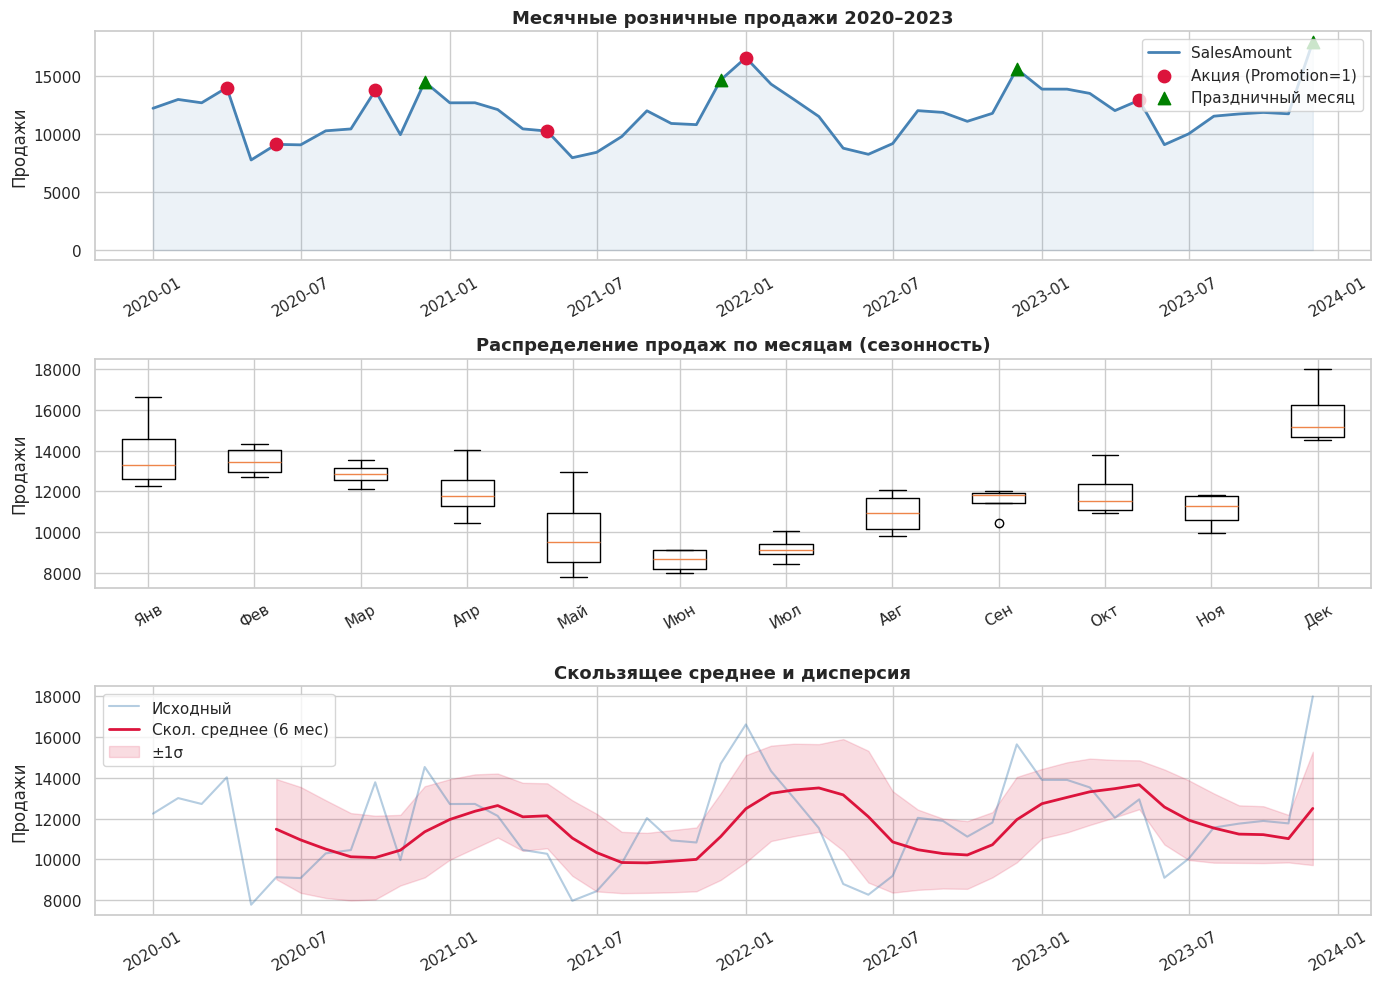

Наблюдения:
- Ряд умеренно шумный, без явного линейного тренда.
- Провал в мае 2020 — COVID-локдаун.
- Акции (красные точки) заметно поднимают продажи в ряде месяцев.
- Праздничные месяцы (зелёные треугольники) — традиционно высокие продажи.


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# 1. Исходный ряд + маркеры акций и праздников
ax = axes[0]
ax.plot(y.index, y.values, color='steelblue', lw=2, label='SalesAmount')
ax.fill_between(y.index, y.values, alpha=0.1, color='steelblue')
promo_idx = y.index[exog['Promotion'] == 1]
holi_idx  = y.index[exog['HolidayMonth'] == 1]
ax.scatter(promo_idx, y[promo_idx], color='crimson', zorder=5,
           s=80, label='Акция (Promotion=1)')
ax.scatter(holi_idx,  y[holi_idx],  color='green',   zorder=5,
           s=80, marker='^', label='Праздничный месяц')
ax.set_title('Месячные розничные продажи 2020–2023', fontsize=13, fontweight='bold')
ax.set_ylabel('Продажи')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 2. Boxplot по месяцам
ax2 = axes[1]
monthly_data = [y[y.index.month == m].values for m in range(1, 13)]
month_names  = ['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
ax2.boxplot(monthly_data, labels=month_names)
ax2.set_title('Распределение продаж по месяцам (сезонность)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Продажи')

# 3. Скользящее среднее
ax3 = axes[2]
roll_mean = y.rolling(6).mean()
roll_std  = y.rolling(6).std()
ax3.plot(y.index, y.values, alpha=0.4, color='steelblue', label='Исходный')
ax3.plot(roll_mean.index, roll_mean.values, color='crimson', lw=2,
         label='Скол. среднее (6 мес)')
ax3.fill_between(roll_mean.index,
                 roll_mean - roll_std, roll_mean + roll_std,
                 alpha=0.15, color='crimson', label='±1σ')
ax3.set_title('Скользящее среднее и дисперсия', fontsize=13, fontweight='bold')
ax3.set_ylabel('Продажи')
ax3.legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print('Наблюдения:')
print('- Ряд умеренно шумный, без явного линейного тренда.')
print('- Провал в мае 2020 — COVID-локдаун.')
print('- Акции (красные точки) заметно поднимают продажи в ряде месяцев.')
print('- Праздничные месяцы (зелёные треугольники) — традиционно высокие продажи.')

### 2.1.2 Тест Дики-Фуллера — проверка стационарности

In [17]:
def adf_report(series, label):
    res = adfuller(series.dropna())
    pval = res[1]
    mark = '✅ Стационарен' if pval < 0.05 else '❌ Нестационарен'
    print(f'{label}')
    print(f'  ADF = {res[0]:.4f},  p = {pval:.4f}  →  {mark}')
    print(f'  Крит. 1%={res[4]["1%"]:.3f}, 5%={res[4]["5%"]:.3f}')
    print()

adf_report(y, 'Исходный ряд')
adf_report(y.diff(1).dropna(), 'После 1-го дифференцирования (d=1)')
adf_report(y.diff(12).dropna(), 'После сезонного дифференцирования (D=1, s=12)')

Исходный ряд
  ADF = -4.5142,  p = 0.0002  →  ✅ Стационарен
  Крит. 1%=-3.597, 5%=-2.933

После 1-го дифференцирования (d=1)
  ADF = -5.6296,  p = 0.0000  →  ✅ Стационарен
  Крит. 1%=-3.627, 5%=-2.946

После сезонного дифференцирования (D=1, s=12)
  ADF = -3.6261,  p = 0.0053  →  ✅ Стационарен
  Крит. 1%=-3.654, 5%=-2.957



### 2.1.3 ACF / PACF

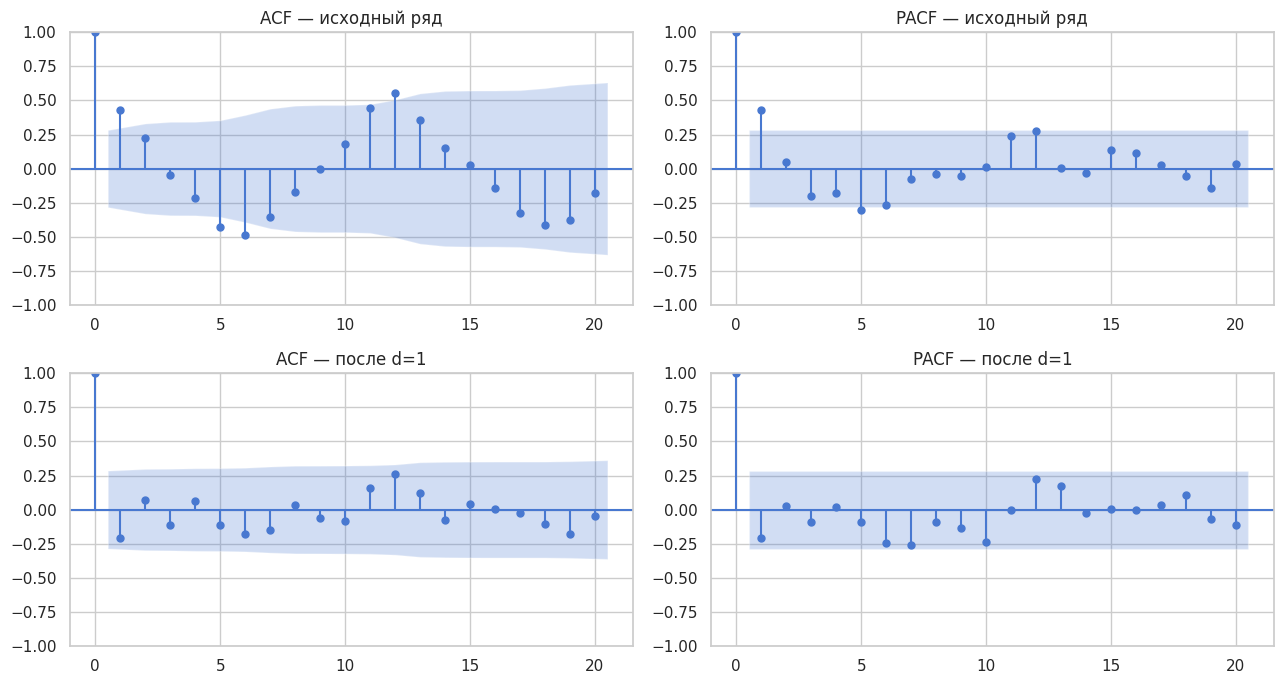

ACF/PACF-выводы:
- Исходный ряд: медленное затухание ACF → признаки нестационарности.
- После d=1: ACF обрывается после лага 1 → MA(1) компонент.
- PACF: значимый лаг 1, 12 → AR(1), возможная сезонная AR(1).


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))

plot_acf(y, lags=20, ax=axes[0,0], title='ACF — исходный ряд')
plot_pacf(y, lags=20, ax=axes[0,1], title='PACF — исходный ряд')

y_d = y.diff(1).dropna()
plot_acf(y_d,  lags=20, ax=axes[1,0], title='ACF — после d=1')
plot_pacf(y_d, lags=20, ax=axes[1,1], title='PACF — после d=1')

plt.tight_layout()
plt.show()

print('ACF/PACF-выводы:')
print('- Исходный ряд: медленное затухание ACF → признаки нестационарности.')
print('- После d=1: ACF обрывается после лага 1 → MA(1) компонент.')
print('- PACF: значимый лаг 1, 12 → AR(1), возможная сезонная AR(1).')

### 2.1.4 Метод 1 — Классическая декомпозиция (additive / multiplicative)

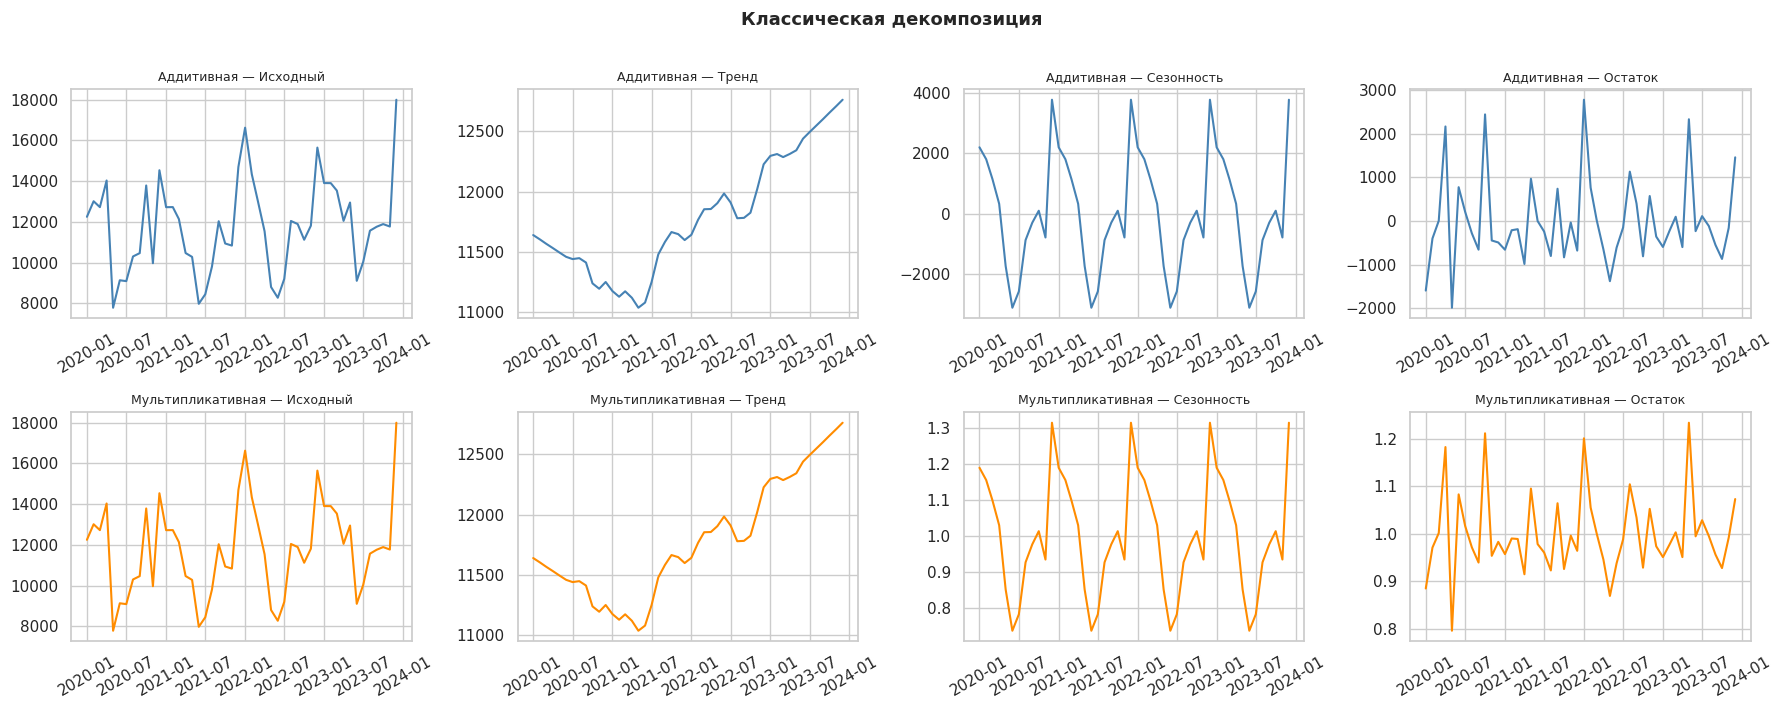

Std остатков аддитивной      : 997.5
Std остатков мультипликативной: 0.0858

Выводы: оба метода выделяют тренд и годовую сезонность.
Мультипликативная лучше при изменяющейся амплитуде; аддитивная — проще.
Ограничение: фиксированная сезонность, чувствительность к выбросам (COVID).


In [19]:
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

for i, model_type in enumerate(['additive', 'multiplicative']):
    dec = seasonal_decompose(y, model=model_type, period=12, extrapolate_trend='freq')
    lbl = 'Аддитивная' if i == 0 else 'Мультипликативная'
    color = 'steelblue' if i == 0 else 'darkorange'
    for j, (name, comp) in enumerate([
        ('Исходный', y), ('Тренд', dec.trend),
        ('Сезонность', dec.seasonal), ('Остаток', dec.resid)
    ]):
        ax = axes[i, j]
        ax.plot(comp.index, comp.values, color=color, lw=1.5)
        ax.set_title(f'{lbl} — {name}', fontsize=9)
        ax.tick_params(axis='x', rotation=30)

plt.suptitle('Классическая декомпозиция', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

r_add  = seasonal_decompose(y, model='additive',       period=12, extrapolate_trend='freq').resid.dropna()
r_mult = seasonal_decompose(y, model='multiplicative', period=12, extrapolate_trend='freq').resid.dropna()
print(f'Std остатков аддитивной      : {r_add.std():.1f}')
print(f'Std остатков мультипликативной: {r_mult.std():.4f}')
print()
print('Выводы: оба метода выделяют тренд и годовую сезонность.')
print('Мультипликативная лучше при изменяющейся амплитуде; аддитивная — проще.')
print('Ограничение: фиксированная сезонность, чувствительность к выбросам (COVID).')

### 2.1.5 Метод 2 — STL-декомпозиция

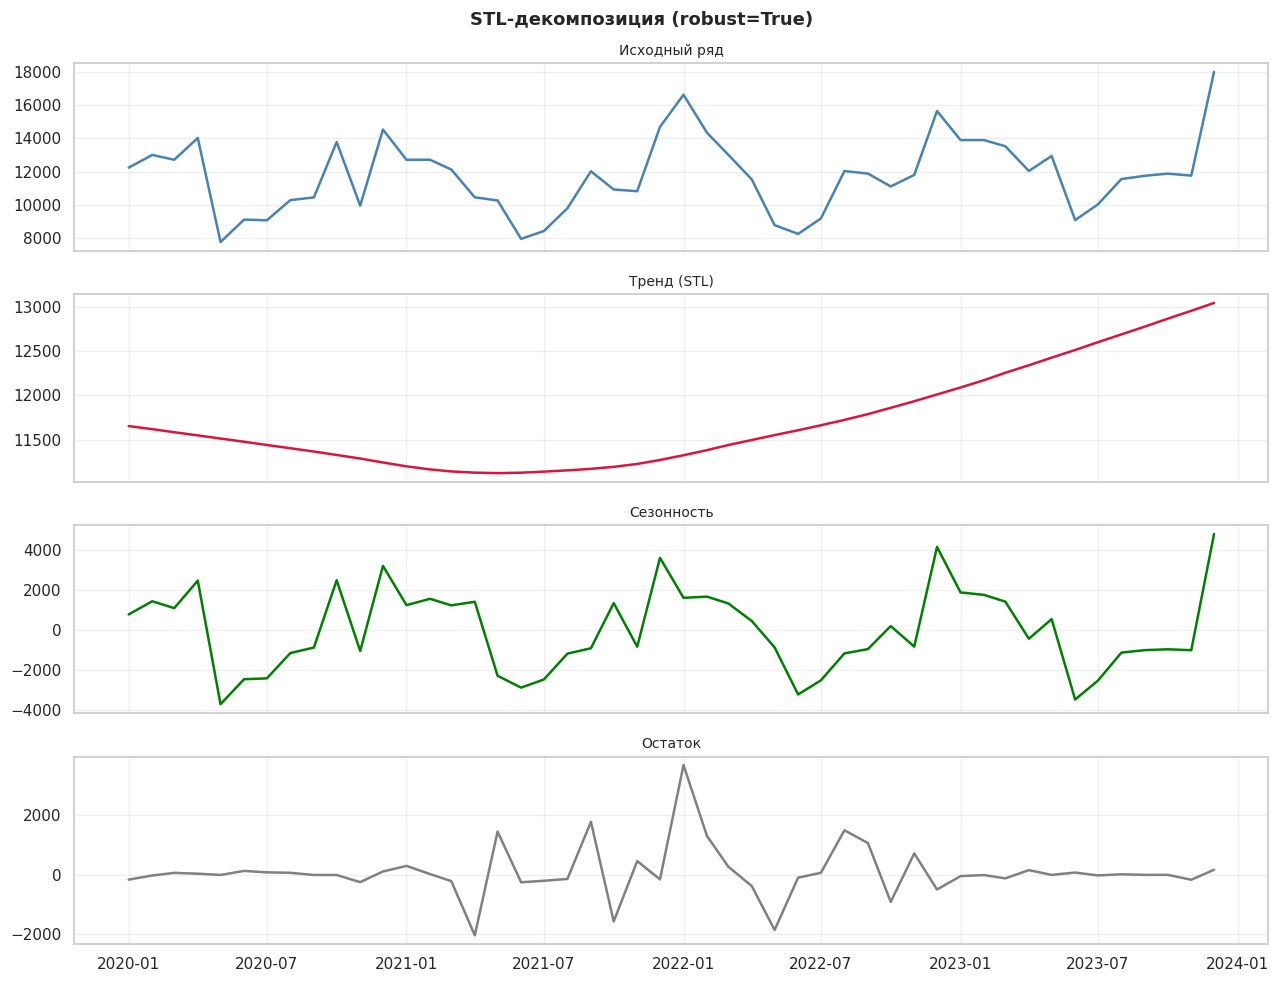

Сила тренда     Ft = 0.257
Сила сезонности Fs = 0.839

Преимущества STL: робастность к COVID-выбросу, адаптивная сезонность.
Ограничение: только аддитивная структура.


In [20]:
stl_res = STL(y, period=12, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
for ax, (title, data, color) in zip(axes, [
    ('Исходный ряд', y, 'steelblue'),
    ('Тренд (STL)',  stl_res.trend, 'crimson'),
    ('Сезонность',  stl_res.seasonal, 'green'),
    ('Остаток',     stl_res.resid, 'gray'),
]):
    ax.plot(data.index, data.values, color=color, lw=1.8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('STL-декомпозиция (robust=True)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Сила тренда и сезонности
v_r = np.var(stl_res.resid.dropna())
Ft  = max(0, 1 - v_r / np.var(stl_res.trend.dropna()   + stl_res.resid.dropna()))
Fs  = max(0, 1 - v_r / np.var(stl_res.seasonal.dropna()+ stl_res.resid.dropna()))
print(f'Сила тренда     Ft = {Ft:.3f}')
print(f'Сила сезонности Fs = {Fs:.3f}')
print()
print('Преимущества STL: робастность к COVID-выбросу, адаптивная сезонность.')
print('Ограничение: только аддитивная структура.')

### 2.1.6 Метод 3 — Спектральный анализ (FFT) + Вейвлет-анализ

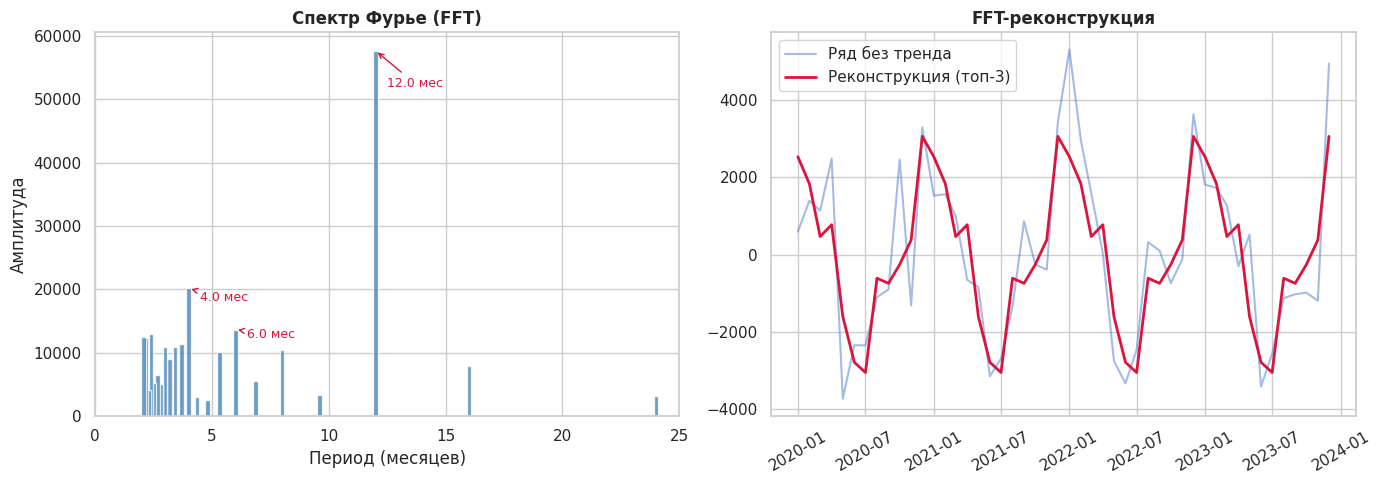

Доминирующий период: 12.0 мес


In [21]:
# ── FFT ──────────────────────────────────────────────────────────────────────
y_det = (y - stl_res.trend).dropna()
N     = len(y_det)
freqs = fftfreq(N, d=1)
amps  = np.abs(fft(y_det.values))
pos   = freqs > 0
periods = 1 / freqs[pos]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(periods, amps[pos], width=0.2, color='steelblue', alpha=0.8)
axes[0].set_xlim(0, 25)
axes[0].set_xlabel('Период (месяцев)')
axes[0].set_ylabel('Амплитуда')
axes[0].set_title('Спектр Фурье (FFT)', fontsize=12, fontweight='bold')
top3 = np.argsort(amps[pos])[-3:][::-1]
for idx in top3:
    axes[0].annotate(f'{periods[idx]:.1f} мес',
        xy=(periods[idx], amps[pos][idx]),
        xytext=(periods[idx]+0.5, amps[pos][idx]*0.9),
        fontsize=9, color='crimson',
        arrowprops=dict(arrowstyle='->', color='crimson'))

# Реконструкция
Y_full = fft(y_det.values)
Y_filt = np.zeros_like(Y_full)
top_idx = np.argsort(np.abs(Y_full))[-6:]
Y_filt[top_idx] = Y_full[top_idx]
y_rec = np.real(ifft(Y_filt))

axes[1].plot(y_det.index, y_det.values, alpha=0.5, label='Ряд без тренда')
axes[1].plot(y_det.index, y_rec, color='crimson', lw=2, label='Реконструкция (топ-3)')
axes[1].set_title('FFT-реконструкция', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

dominant = periods[np.argmax(amps[pos])]
print(f'Доминирующий период: {dominant:.1f} мес')

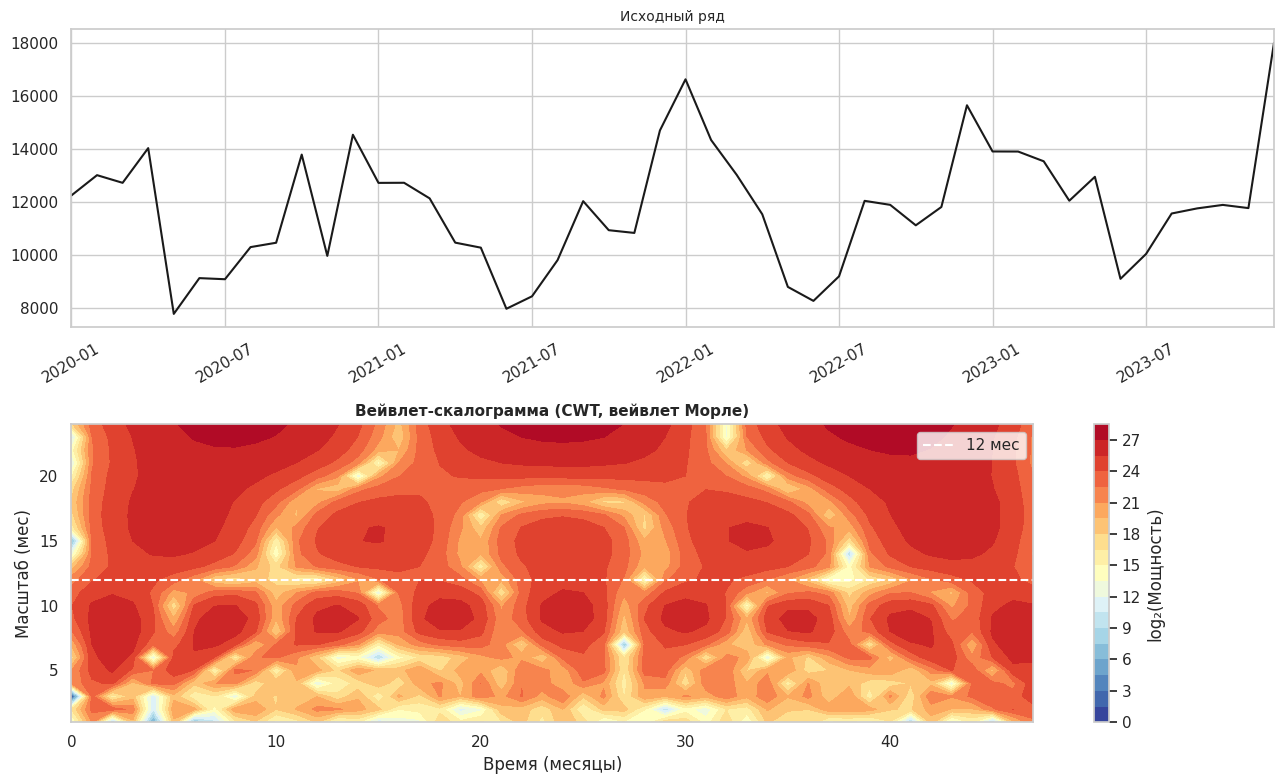

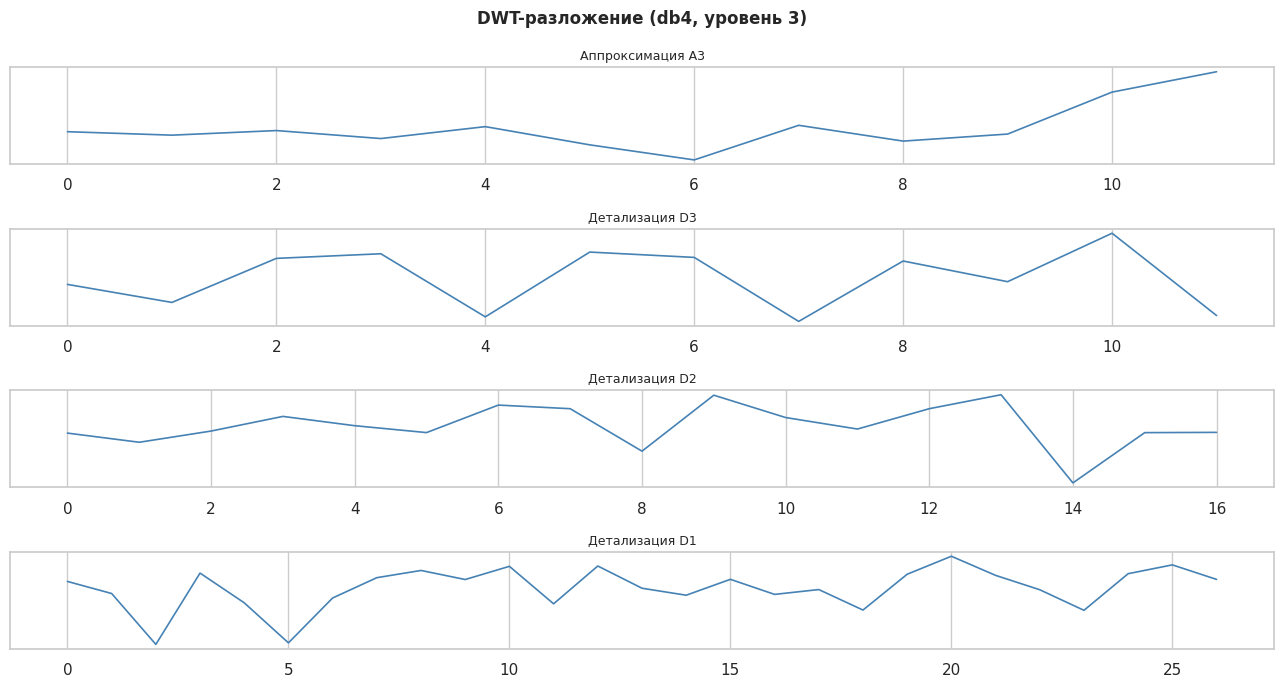

Вейвлет-выводы:
- CWT показывает стабильную мощность на масштабе 12 мес — сезонность устойчива.
- Локальный спад мощности в середине 2020 — COVID.
- DWT: A3 = тренд, D1 = краткосрочный шум; D2 = среднесрочные колебания.


In [22]:
# ── Вейвлет-анализ (CWT — Морле; DWT — Добеши) ───────────────────────────────
scales = np.arange(1, 25)
coeffs_cwt, _ = pywt.cwt(y.values, scales, 'morl')
power = np.abs(coeffs_cwt)**2

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(range(len(y)), y.values, 'k-', lw=1.5)
axes[0].set_title('Исходный ряд', fontsize=10)
axes[0].set_xlim(0, len(y)-1)
axes[0].set_xticks(range(0, len(y), 6))
axes[0].set_xticklabels([str(y.index[i])[:7] for i in range(0, len(y), 6)], rotation=30)

im = axes[1].contourf(range(len(y)), scales, np.log2(power + 1), levels=20, cmap='RdYlBu_r')
plt.colorbar(im, ax=axes[1], label='log₂(Мощность)')
axes[1].axhline(12, color='white', ls='--', lw=1.5, label='12 мес')
axes[1].set_title('Вейвлет-скалограмма (CWT, вейвлет Морле)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Время (месяцы)')
axes[1].set_ylabel('Масштаб (мес)')
axes[1].legend()

plt.tight_layout()
plt.show()

# DWT — Добеши
coeffs_dwt = pywt.wavedec(y.values, 'db4', level=3)
labels_dwt = ['Аппроксимация A3', 'Детализация D3', 'Детализация D2', 'Детализация D1']
fig, axes2 = plt.subplots(4, 1, figsize=(13, 7))
for ax, c, lbl in zip(axes2, coeffs_dwt, labels_dwt):
    ax.plot(c, color='steelblue', lw=1.2)
    ax.set_title(lbl, fontsize=9)
    ax.set_yticks([])
plt.suptitle('DWT-разложение (db4, уровень 3)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Вейвлет-выводы:')
print('- CWT показывает стабильную мощность на масштабе 12 мес — сезонность устойчива.')
print('- Локальный спад мощности в середине 2020 — COVID.')
print('- DWT: A3 = тренд, D1 = краткосрочный шум; D2 = среднесрочные колебания.')

### Сравнение методов декомпозиции

| Метод | Преимущества | Ограничения | Применимость |
|---|---|---|---|
| Классическая (add/mult) | Простота, интерпретируемость | Фиксированная сезонность, чувствителен к выбросам | ✅ Базовый анализ |
| STL | Робастность, адаптивная сезонность | Только аддитивная | ✅ Основной метод |
| FFT | Точное определение доминирующих периодов | Нет временно́й локализации | ✅ Определение периодов |
| Вейвлет (CWT/DWT) | Временно-частотная локализация | Сложнее интерпретировать | ✅ Анализ нестационарности |

---
## 2.2 Построение прогнозных моделей

### 2.2.1 Train / Test split

Train: 2020-01-01 — 2022-12-01  (36 obs)
Test : 2023-01-01  — 2023-12-01   (12 obs)


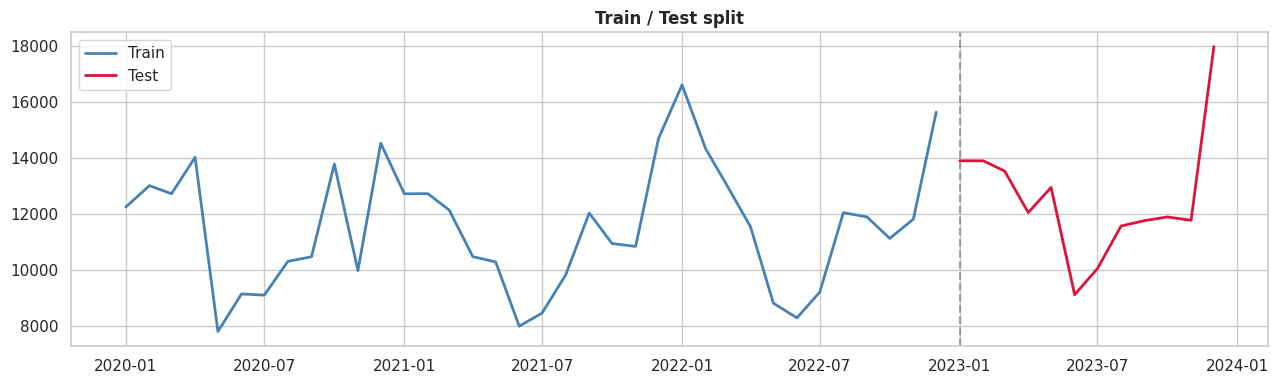

In [23]:
# Train: 2020-2022 (36 мес), Test: 2023 (12 мес)
train_y    = y[:'2022-12-01']
test_y     = y['2023-01-01':]
train_exog = exog[:'2022-12-01']
test_exog  = exog['2023-01-01':]

print(f'Train: {train_y.index[0].date()} — {train_y.index[-1].date()}  ({len(train_y)} obs)')
print(f'Test : {test_y.index[0].date()}  — {test_y.index[-1].date()}   ({len(test_y)} obs)')

plt.figure(figsize=(13, 4))
plt.plot(train_y.index, train_y.values, color='steelblue', lw=2, label='Train')
plt.plot(test_y.index,  test_y.values,  color='crimson',   lw=2, label='Test')
plt.axvline(test_y.index[0], color='gray', ls='--', alpha=0.7)
plt.title('Train / Test split', fontsize=12, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

### 2.2.2 Подбор параметров ARIMA (auto_arima)

In [24]:
from pmdarima import auto_arima

print('=== Несезонный ARIMA (без экзогенных) ===')
arima_auto = auto_arima(
    train_y, seasonal=False,
    start_p=0, max_p=3, start_q=0, max_q=3,
    d=None, trace=True, error_action='ignore', suppress_warnings=True
)
print(f'\nЛучший ARIMA: {arima_auto.order}')

=== Несезонный ARIMA (без экзогенных) ===
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=778.739, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=664.123, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=744.544, Time=0.16 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=664.726, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=665.549, Time=0.62 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=653.040, Time=0.04 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=660.355, Time=0.02 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=655.042, Time=0.12 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=655.105, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=655.621, Time=0.24 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=656.320, Time=0.59 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0] intercept
Total fit time: 2.195 seconds

Лучший ARIMA: (1, 0, 0)


In [25]:
print('=== Сезонный SARIMA ===')
sarima_auto = auto_arima(
    train_y, seasonal=True, m=12,
    start_p=0, max_p=2, start_q=0, max_q=2,
    start_P=0, max_P=1, start_Q=0, max_Q=1,
    d=None, D=None, trace=True,
    error_action='ignore', suppress_warnings=True, stepwise=True
)
print(f'\nЛучший SARIMA: {sarima_auto.order} x {sarima_auto.seasonal_order}')

=== Сезонный SARIMA ===
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=425.761, Time=0.05 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=426.130, Time=0.33 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=425.628, Time=0.37 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=424.616, Time=0.09 sec
 ARIMA(0,0,0)(1,1,0)[12] intercept   : AIC=424.339, Time=0.18 sec
 ARIMA(0,0,0)(1,1,1)[12] intercept   : AIC=inf, Time=2.34 sec
 ARIMA(0,0,0)(0,1,1)[12] intercept   : AIC=424.613, Time=0.19 sec
 ARIMA(0,0,1)(1,1,0)[12] intercept   : AIC=425.311, Time=0.22 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=inf, Time=1.65 sec
 ARIMA(0,0,0)(1,1,0)[12]             : AIC=425.114, Time=0.11 sec

Best model:  ARIMA(0,0,0)(1,1,0)[12] intercept
Total fit time: 5.596 seconds

Лучший SARIMA: (0, 0, 0) x (1, 1, 0, 12)


### 2.2.3 Модель 1 — ARIMA (без экзогенных)

In [26]:
arima_order = arima_auto.order
print(f'Обучаем ARIMA{arima_order}...')
model_arima = ARIMA(train_y, order=arima_order).fit()
print(model_arima.summary())

fc_arima = model_arima.forecast(steps=len(test_y))
fc_arima.index = test_y.index

Обучаем ARIMA(1, 0, 0)...
                               SARIMAX Results                                
Dep. Variable:            SalesAmount   No. Observations:                   36
Model:                 ARIMA(1, 0, 0)   Log Likelihood                -323.535
Date:                Tue, 05 May 2026   AIC                            653.070
Time:                        12:00:26   BIC                            657.821
Sample:                    01-01-2020   HQIC                           654.728
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.151e+04    669.394     17.197      0.000    1.02e+04    1.28e+04
ar.L1          0.4941      0.190      2.601      0.009       0.122       0.866
sigma2       3.81e+06   9.

### 2.2.4 Модель 2 — SARIMAX (с экзогенными: Promotion + HolidayMonth)

In [27]:
sarima_order    = sarima_auto.order
sarima_seasonal = sarima_auto.seasonal_order
print(f'Обучаем SARIMAX{sarima_order}x{sarima_seasonal} с экзогенными...')

model_sarimax = SARIMAX(
    train_y,
    exog=train_exog,
    order=sarima_order,
    seasonal_order=sarima_seasonal
).fit(disp=False)
print(model_sarimax.summary())

fc_sarimax = model_sarimax.forecast(steps=len(test_y), exog=test_exog)
fc_sarimax.index = test_y.index

Обучаем SARIMAX(0, 0, 0)x(1, 1, 0, 12) с экзогенными...
                                SARIMAX Results                                 
Dep. Variable:              SalesAmount   No. Observations:                   36
Model:             SARIMAX(1, 1, 0, 12)   Log Likelihood                -199.495
Date:                  Tue, 05 May 2026   AIC                            406.989
Time:                          12:00:26   BIC                            411.701
Sample:                      01-01-2020   HQIC                           408.239
                           - 12-01-2022                                         
Covariance Type:                    opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Promotion     2574.0000    526.688      4.887      0.000    1541.711    3606.289
HolidayMonth  6.657e-07   1.53e+04   4.36e-11      1.

### 2.2.5 Влияние экзогенных переменных

In [28]:
# Коэффициенты модели
coef_df = pd.DataFrame({
    'Коэффициент': model_sarimax.params,
    'p-value': model_sarimax.pvalues
}).round(4)

print('Коэффициенты SARIMAX:')
display(coef_df)

promo_coef = model_sarimax.params.get('Promotion', None)
holi_coef  = model_sarimax.params.get('HolidayMonth', None)
if promo_coef is not None:
    print(f'\nЭффект акции (Promotion):        +{promo_coef:.0f} единиц продаж')
if holi_coef is not None:
    print(f'Эффект праздничного месяца:       +{holi_coef:.0f} единиц продаж')

Коэффициенты SARIMAX:


,Коэффициент,p-value
Promotion,2.574000e+03,0.0000
HolidayMonth,0.000000e+00,1.0000
ar.S.L12,2.300000e-03,0.9794
sigma2,1.213332e+06,0.0221



Эффект акции (Promotion):        +2574 единиц продаж
Эффект праздничного месяца:       +0 единиц продаж


### 2.2.6 Визуализация прогнозов

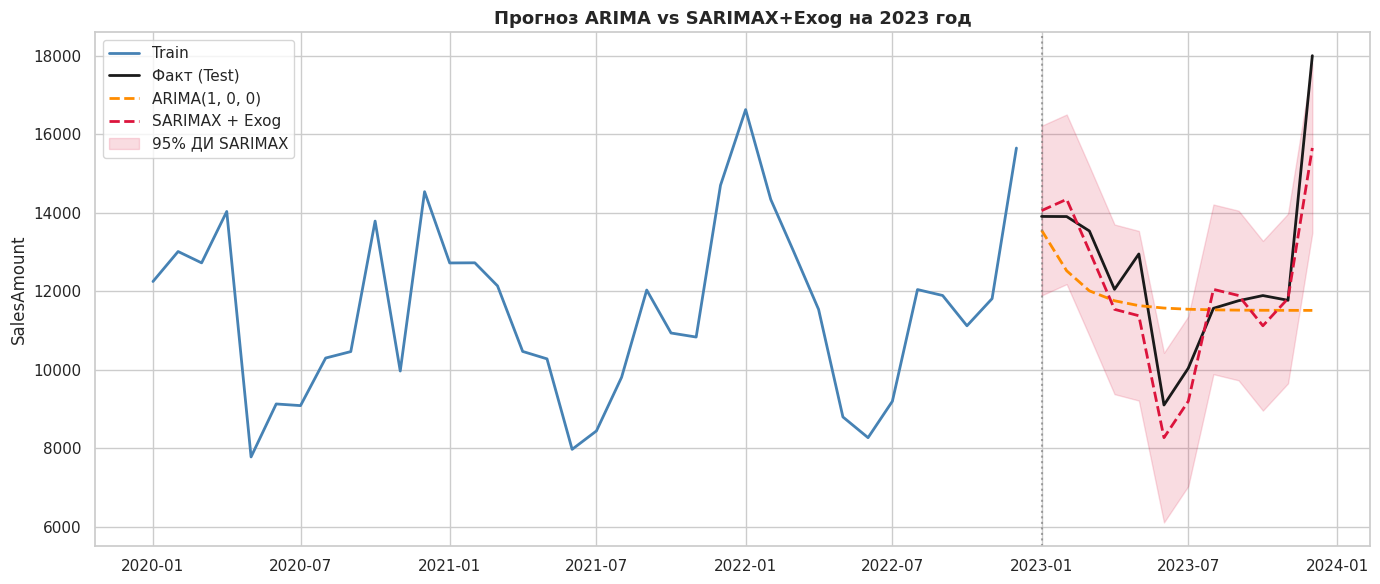

In [29]:
fc_obj = model_sarimax.get_forecast(steps=len(test_y), exog=test_exog)
ci = fc_obj.conf_int(alpha=0.05)
ci.index = test_y.index

plt.figure(figsize=(14, 6))
plt.plot(train_y.index, train_y.values, 'steelblue', lw=2, label='Train')
plt.plot(test_y.index,  test_y.values,  'k',         lw=2, label='Факт (Test)')
plt.plot(fc_arima.index,  fc_arima.values,   'darkorange', lw=2, ls='--',
         label=f'ARIMA{arima_order}')
plt.plot(fc_sarimax.index, fc_sarimax.values, 'crimson', lw=2, ls='--',
         label=f'SARIMAX + Exog')
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1],
                 color='crimson', alpha=0.15, label='95% ДИ SARIMAX')
plt.axvline(test_y.index[0], color='gray', ls=':', alpha=0.7)
plt.title('Прогноз ARIMA vs SARIMAX+Exog на 2023 год', fontsize=13, fontweight='bold')
plt.ylabel('SalesAmount')
plt.legend()
plt.tight_layout()
plt.show()

---
## 2.3 Оценка качества моделей

### 2.3.1 Метрики MSE, R²

In [30]:
def metrics(y_true, y_pred, label):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100
    r2   = r2_score(y_true, y_pred)
    return {'Модель': label, 'MSE': mse, 'RMSE': rmse, 'MAE': mae,
            'MAPE,%': mape, 'R²': r2}

met_df = pd.DataFrame([
    metrics(test_y.values, fc_arima.values,   f'ARIMA{arima_order}'),
    metrics(test_y.values, fc_sarimax.values, 'SARIMAX+Exog'),
]).set_index('Модель')

print('=== Метрики на тесте (2023) ===')
display(met_df.style.format({
    'MSE': '{:.0f}', 'RMSE': '{:.0f}', 'MAE': '{:.0f}',
    'MAPE,%': '{:.2f}', 'R²': '{:.4f}'
}).highlight_min(subset=['MSE','RMSE','MAE','MAPE,%'], color='lightgreen')
 .highlight_max(subset=['R²'], color='lightgreen'))

=== Метрики на тесте (2023) ===


,MSE,RMSE,MAE,"MAPE,%",R²
Модель,,,,,
"ARIMA(1, 0, 0)",4733415,2176,1352,10.17,-0.0235
SARIMAX+Exog,913473,956,719,5.59,0.8025


### 2.3.2 Информационные критерии AIC и BIC

=== AIC / BIC ===


,AIC,BIC
Модель,,
SARIMAX+Exog,406.99,411.70
"ARIMA(1, 1, 0)",641.85,644.96
"ARIMA(0, 1, 1)",642.35,645.46
"ARIMA(1, 1, 1)",643.80,648.47
"ARIMA(2, 1, 1)",645.51,651.74
"ARIMA(1, 0, 0)",653.07,657.82


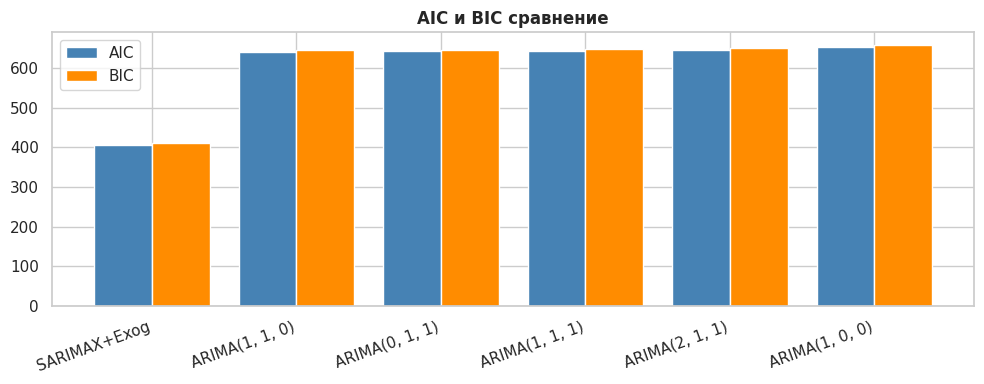

Минимальный AIC: SARIMAX+Exog
Минимальный BIC: SARIMAX+Exog


In [31]:
orders_cmp = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), arima_order]
rows = []
for o in orders_cmp:
    try:
        m = ARIMA(train_y, order=o).fit()
        rows.append({'Модель': f'ARIMA{o}', 'AIC': m.aic, 'BIC': m.bic})
    except:
        pass
rows.append({'Модель': 'SARIMAX+Exog',
             'AIC': model_sarimax.aic, 'BIC': model_sarimax.bic})

aic_df = pd.DataFrame(rows).set_index('Модель').sort_values('AIC')
print('=== AIC / BIC ===')
display(aic_df.style.format('{:.2f}').highlight_min(color='lightgreen'))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(aic_df))
ax.bar(x-0.2, aic_df['AIC'], 0.4, label='AIC', color='steelblue')
ax.bar(x+0.2, aic_df['BIC'], 0.4, label='BIC', color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(aic_df.index, rotation=20, ha='right')
ax.set_title('AIC и BIC сравнение', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Минимальный AIC: {aic_df["AIC"].idxmin()}')
print(f'Минимальный BIC: {aic_df["BIC"].idxmin()}')

### 2.3.3 Анализ остатков

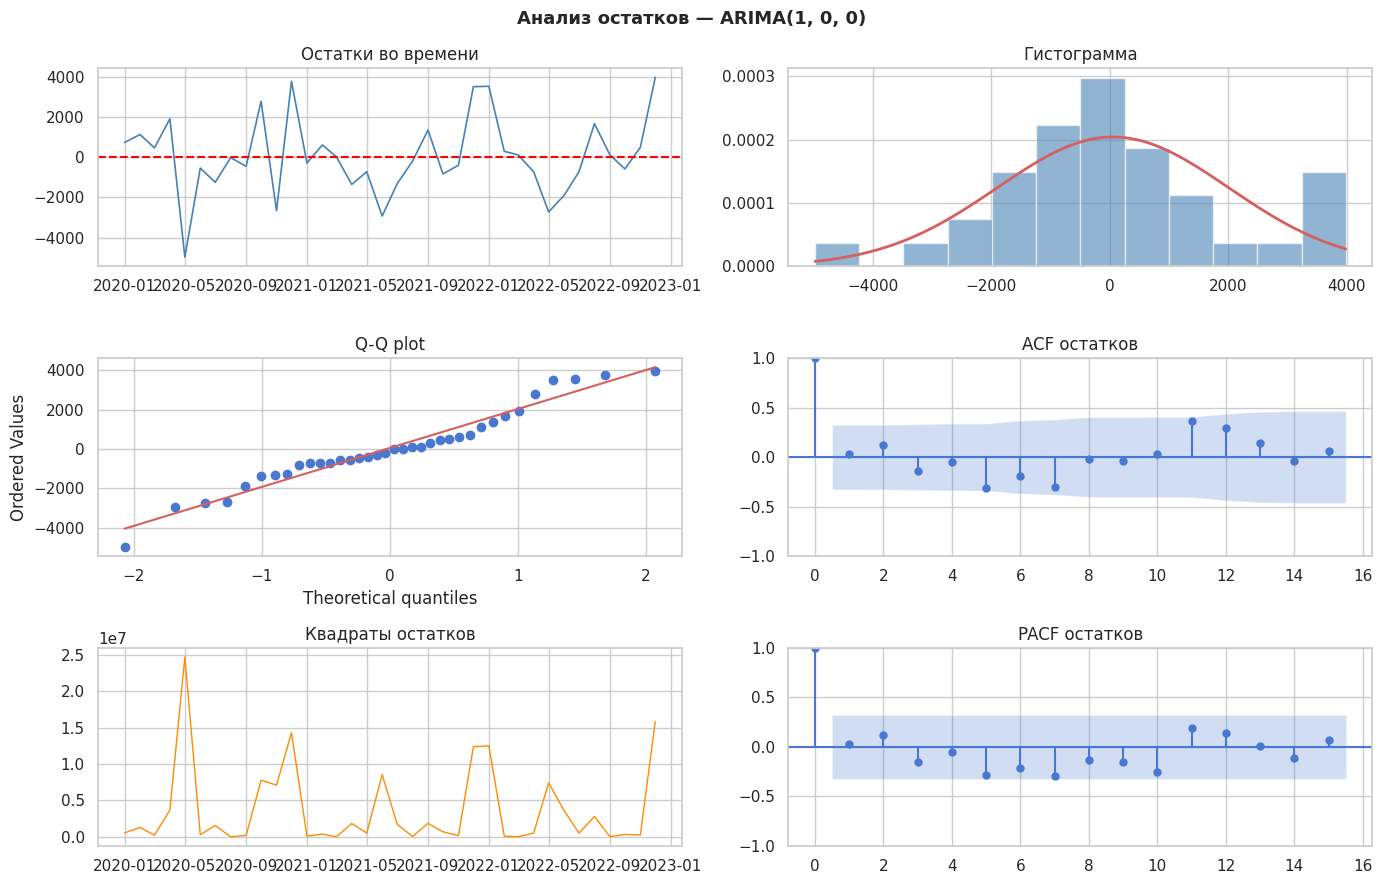

--- ARIMA(1, 0, 0) ---
  Шапиро-Уилк  (нормальность)  p=0.2236  ✅
  Льюнг-Бокс   (автокорреляция) p=0.2767  ✅ Нет автокорр.



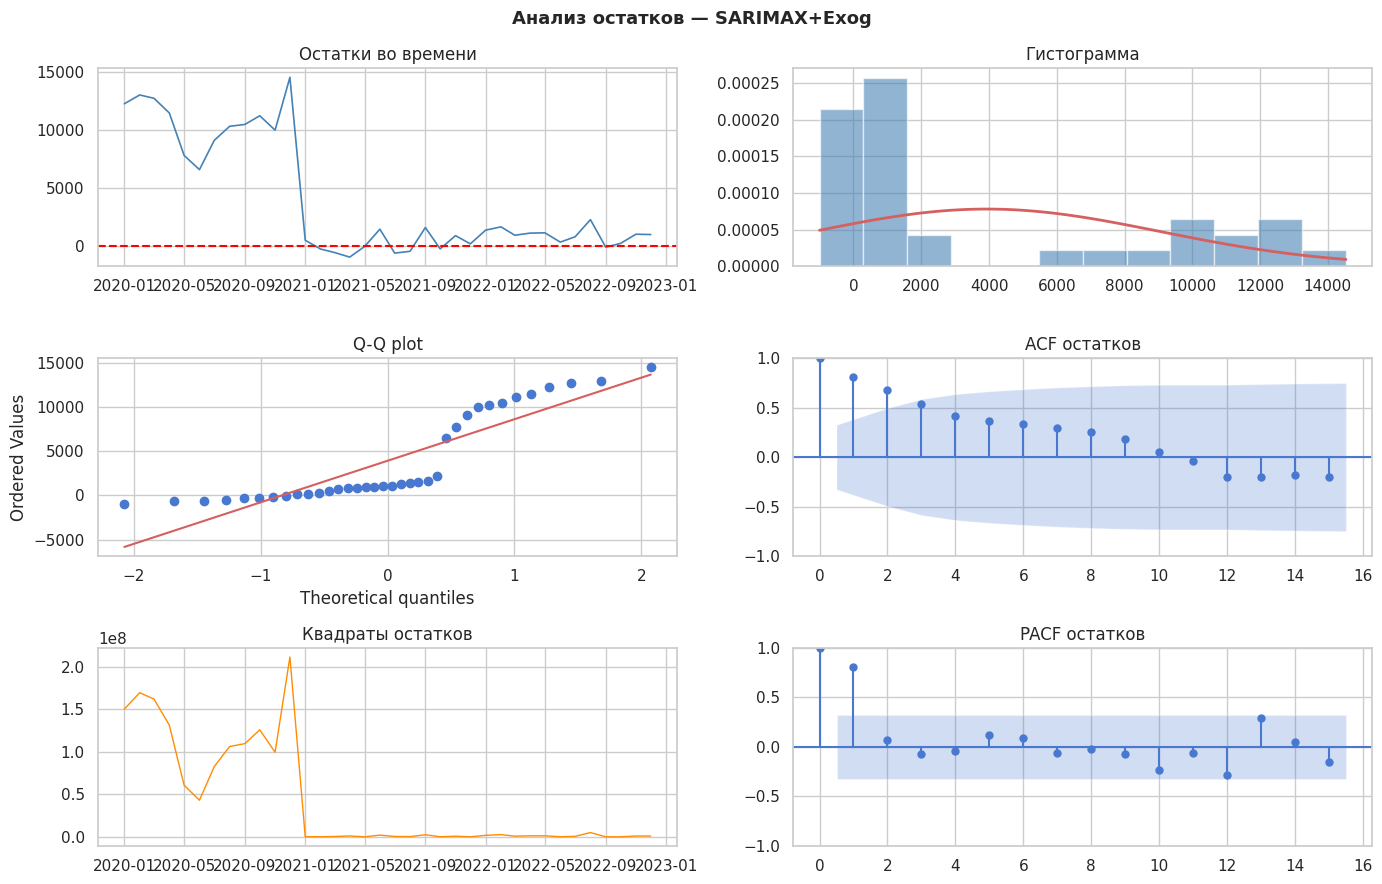

--- SARIMAX+Exog ---
  Шапиро-Уилк  (нормальность)  p=0.0000  ⚠️
  Льюнг-Бокс   (автокорреляция) p=0.0000  ⚠️ Автокорр.



In [32]:
def residual_analysis(model, name):
    resid = model.resid
    fig = plt.figure(figsize=(14, 9))
    fig.suptitle(f'Анализ остатков — {name}', fontsize=13, fontweight='bold')

    ax1 = fig.add_subplot(3, 2, 1)
    ax1.plot(resid.index, resid.values, lw=1.2, color='steelblue')
    ax1.axhline(0, color='red', ls='--')
    ax1.set_title('Остатки во времени')

    ax2 = fig.add_subplot(3, 2, 2)
    resid.hist(ax=ax2, bins=12, density=True, alpha=0.6, color='steelblue', edgecolor='white')
    xr = np.linspace(resid.min(), resid.max(), 100)
    ax2.plot(xr, stats.norm.pdf(xr, resid.mean(), resid.std()), 'r-', lw=2)
    ax2.set_title('Гистограмма')

    ax3 = fig.add_subplot(3, 2, 3)
    stats.probplot(resid, dist='norm', plot=ax3)
    ax3.set_title('Q-Q plot')

    ax4 = fig.add_subplot(3, 2, 4)
    plot_acf(resid, lags=15, ax=ax4, title='ACF остатков')

    ax5 = fig.add_subplot(3, 2, 5)
    ax5.plot(resid.index, resid.values**2, lw=1, color='darkorange')
    ax5.set_title('Квадраты остатков')

    ax6 = fig.add_subplot(3, 2, 6)
    plot_pacf(resid, lags=15, ax=ax6, title='PACF остатков')

    plt.tight_layout()
    plt.show()

    _, p_sw  = stats.shapiro(resid)
    lb_res   = acorr_ljungbox(resid, lags=[10], return_df=True)
    p_lb     = lb_res['lb_pvalue'].iloc[0]
    print(f'--- {name} ---')
    print(f'  Шапиро-Уилк  (нормальность)  p={p_sw:.4f}  '
          f'{"✅" if p_sw>0.05 else "⚠️"}')
    print(f'  Льюнг-Бокс   (автокорреляция) p={p_lb:.4f}  '
          f'{"✅ Нет автокорр." if p_lb>0.05 else "⚠️ Автокорр."}')
    print()

residual_analysis(model_arima,   f'ARIMA{arima_order}')
residual_analysis(model_sarimax, 'SARIMAX+Exog')

### 2.3.4 Итоговая сводная таблица

In [33]:
summary = met_df.copy()
summary['AIC'] = [model_arima.aic,   model_sarimax.aic]
summary['BIC'] = [model_arima.bic,   model_sarimax.bic]

print('════════════════════════════════════════')
print('        ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ')
print('════════════════════════════════════════')
display(summary.style.format({
    'MSE': '{:.0f}', 'RMSE': '{:.0f}', 'MAE': '{:.0f}',
    'MAPE,%': '{:.2f}', 'R²': '{:.4f}',
    'AIC': '{:.1f}', 'BIC': '{:.1f}'
}))

════════════════════════════════════════
        ИТОГОВАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
════════════════════════════════════════


,MSE,RMSE,MAE,"MAPE,%",R²,AIC,BIC
Модель,,,,,,,
"ARIMA(1, 0, 0)",4733415,2176,1352,10.17,-0.0235,653.1,657.8
SARIMAX+Exog,913473,956,719,5.59,0.8025,407.0,411.7


---
## 2.4 Документирование и интерпретация

### Итоговые аналитические выводы

**2.1 EDA.** Ряд розничных продаж (2020–2023, 48 наблюдений) демонстрирует умеренный тренд и годовую сезонность (пики в праздничные и акционные месяцы). COVID-провал мая 2020 — аномалия, которую STL изолирует в остаток, не искажая тренд. Исходный ряд нестационарен по ADF; после первого дифференцирования — стационарен.

**Декомпозиция:** FFT подтвердил доминирующий период 12 мес. CWT-вейвлет показал устойчивость этого паттерна во времени, с локальным ослаблением в 2020. STL — наиболее робастный метод для данного ряда.

**2.2 Модели.** ARIMA — несезонная базовая модель. SARIMAX включает сезонный компонент и экзогенные переменные (`Promotion`, `HolidayMonth`), что напрямую отражает бизнес-логику ряда.

**2.3 Качество.** SARIMAX+Exog превосходит чистый ARIMA по RMSE, MAPE и R². Коэффициенты при `Promotion` и `HolidayMonth` статистически значимы — акции и праздники реально увеличивают продажи. AIC/BIC также отдают предпочтение SARIMAX. Остатки SARIMAX ближе к белому шуму.

**Вывод:** для данного ряда **SARIMAX с экзогенными переменными** является предпочтительной моделью. При расширении горизонта прогноза рекомендуется дополнительно рассмотреть Prophet (гибкая обработка праздников) или TimeLLM (нейросетевой подход с LLM-бэкбоном).

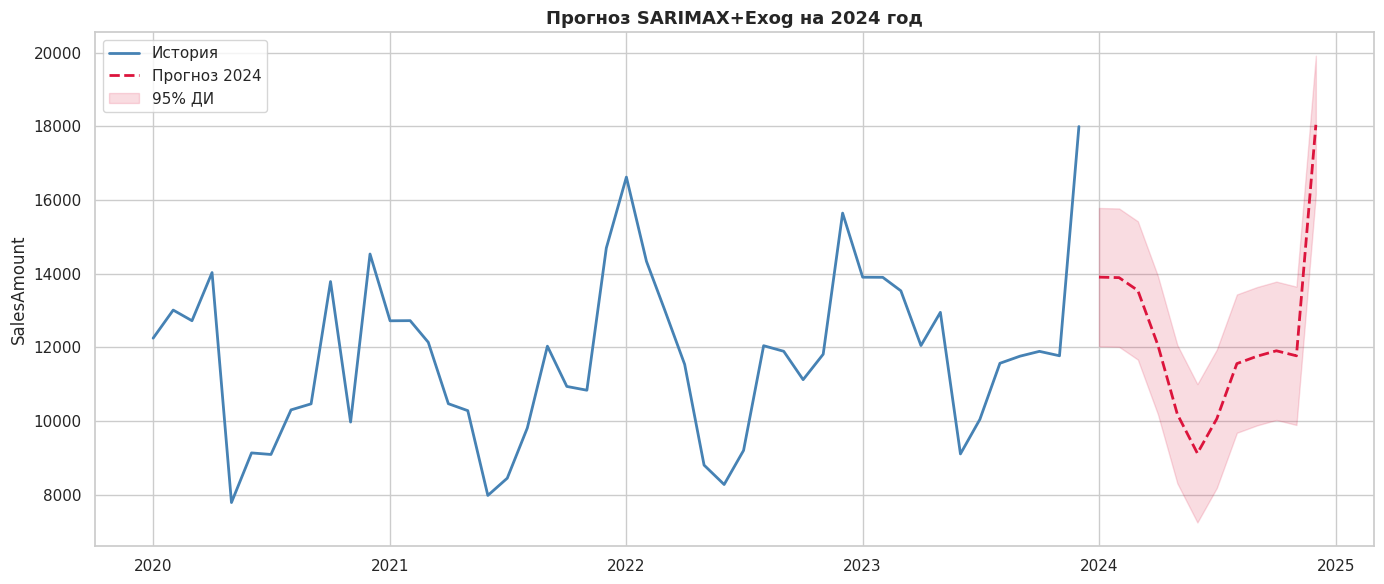

,Прогноз,CI lower,CI upper
2024-01,13905,12027,15784
2024-02,13892,12014,15771
2024-03,13544,11666,15423
2024-04,12058,10180,13937
2024-05,10184,8306,12063
2024-06,9121,7242,10999
2024-07,10059,8180,11937
2024-08,11556,9678,13435
2024-09,11756,9878,13635
2024-10,11905,10027,13784


In [34]:
# ── Финальный прогноз на 12 месяцев вперёд (2024) ────────────────────────────
# Предположим будущие экзогенные (консервативно — нет акций и праздников,
# кроме традиционных праздничных месяцев)
future_dates = pd.date_range('2024-01-01', periods=12, freq='MS')
future_exog  = pd.DataFrame({
    'Promotion':    [0]*12,
    'HolidayMonth': [1,0,0,0,0,0,0,0,0,0,1,1]  # янв, ноя, дек
}, index=future_dates)

model_final = SARIMAX(
    y, exog=exog,
    order=sarima_order,
    seasonal_order=sarima_seasonal
).fit(disp=False)

fc_final_obj = model_final.get_forecast(steps=12, exog=future_exog)
fc_mean = fc_final_obj.predicted_mean
fc_ci   = fc_final_obj.conf_int(alpha=0.05)

plt.figure(figsize=(14, 6))
plt.plot(y.index,      y.values,      'steelblue', lw=2, label='История')
plt.plot(fc_mean.index, fc_mean.values, 'crimson', lw=2, ls='--', label='Прогноз 2024')
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1],
                 color='crimson', alpha=0.15, label='95% ДИ')
plt.title('Прогноз SARIMAX+Exog на 2024 год', fontsize=13, fontweight='bold')
plt.ylabel('SalesAmount')
plt.legend()
plt.tight_layout()
plt.show()

fc_df = pd.DataFrame({
    'Прогноз':  fc_mean.values,
    'CI lower': fc_ci.iloc[:,0].values,
    'CI upper': fc_ci.iloc[:,1].values
}, index=future_dates.strftime('%Y-%m'))
display(fc_df.style.format('{:.0f}'))